# TensorFlow/Keras LSTM 기반 항공 승객 수 예측 실습

목표는 월별 항공 승객 수 데이터를 사용하여 **과거 12개월 승객 수로 다음 1개월 승객 수를 예측하는 LSTM 회귀 모델**을 만드는 것입니다.

전체 흐름은 다음과 같습니다.

1. 필요한 패키지 불러오기
2. 하이퍼파라미터 설정
3. 데이터 불러오기
4. 데이터 정규화
5. 시계열 입력/정답 데이터 생성
6. 학습 데이터와 테스트 데이터 분리
7. TensorFlow 입력 데이터 준비
8. TensorFlow/Keras LSTM 모델 정의
9. 손실 함수와 최적화 알고리즘 설정
10. 모델 학습
11. 학습 손실 시각화
12. 모델 평가
13. 예측값을 원래 승객 수 단위로 복원
14. 예측 결과 시각화
15. 다음 1개월 승객 수 예측


## 1. 패키지 임포트

아래 코드는 데이터 처리, 시각화, 전처리, TensorFlow/Keras 딥러닝 모델 학습에 필요한 라이브러리를 불러옵니다.


In [1]:
# 운영체제 관련 기능을 사용하기 위한 표준 라이브러리입니다.
# 예를 들어 현재 작업 폴더에 CSV 파일이 존재하는지 확인할 때 사용합니다.
import os

# 학습 시간을 측정하기 위해 time 함수를 불러옵니다.
# 모델 학습에 걸린 전체 시간을 확인할 때 사용합니다.
from time import time

# numpy는 배열 기반 수치 계산을 빠르게 처리하기 위해 사용하는 라이브러리입니다.
# 시계열 데이터를 입력 X와 정답 y 배열로 변환할 때 사용합니다.
import numpy as np

# pandas는 CSV 파일을 읽고 표 형태의 데이터를 처리하기 위해 사용하는 라이브러리입니다.
# 항공 승객 수 데이터를 DataFrame 형태로 불러올 때 사용합니다.
import pandas as pd

# matplotlib.pyplot은 선 그래프, 손실 그래프, 예측 결과 그래프를 그릴 때 사용하는 라이브러리입니다.
import matplotlib.pyplot as plt

# MinMaxScaler는 데이터를 0과 1 사이 범위로 변환하는 정규화 도구입니다.
# 승객 수처럼 값의 크기가 큰 데이터를 신경망이 학습하기 쉽게 바꿀 때 사용합니다.
from sklearn.preprocessing import MinMaxScaler

# mean_squared_error는 예측값과 실제값 사이의 평균제곱오차를 계산하는 평가 함수입니다.
# 원래 승객 수 단위로 복원한 뒤 모델 성능을 확인할 때 사용합니다.
from sklearn.metrics import mean_squared_error

# tensorflow는 딥러닝 모델 생성, 학습, 평가를 수행하는 대표적인 딥러닝 라이브러리입니다.
import tensorflow as tf

# keras는 TensorFlow 안에서 신경망 모델을 쉽게 구성할 수 있게 해주는 고수준 API입니다.
from tensorflow import keras

# layers는 LSTM, Dense, Input 같은 신경망 계층을 생성할 때 사용합니다.
from tensorflow.keras import layers

# numpy 배열 출력 시 소수점 자릿수를 3자리로 제한하여 결과를 보기 쉽게 만듭니다.
np.set_printoptions(precision=3, suppress=True)

# numpy 난수 시드를 고정하여 매번 비슷한 데이터 처리 결과가 나오도록 합니다.
np.random.seed(42)

# TensorFlow 난수 시드를 고정하여 모델 초기 가중치가 매번 비슷하게 생성되도록 합니다.
tf.random.set_seed(42)

# 현재 TensorFlow 버전을 출력합니다.
# 구글 코랩 또는 로컬 환경에서 TensorFlow가 정상적으로 설치되었는지 확인할 수 있습니다.
print("TensorFlow 버전:", tf.__version__)

# TensorFlow가 사용할 수 있는 GPU 목록을 확인합니다.
# GPU가 표시되면 학습 속도가 더 빨라질 수 있습니다.
print("사용 가능한 GPU:", tf.config.list_physical_devices("GPU"))


TensorFlow 버전: 2.20.0
사용 가능한 GPU: []


## 2. 하이퍼파라미터 설정

하이퍼파라미터는 모델이 자동으로 학습하는 값이 아니라, 사람이 직접 정하는 학습 설정값입니다.


In [2]:
# 과거 몇 개월의 데이터를 입력으로 사용할지 정합니다.
# 12로 설정하면 과거 12개월 승객 수를 보고 다음 1개월 승객 수를 예측합니다.
PAST_MONTHS = 12

# 전체 데이터 중 학습 데이터로 사용할 비율입니다.
# 0.8은 앞쪽 80% 데이터를 학습에 사용하고, 뒤쪽 20% 데이터를 테스트에 사용한다는 의미입니다.
TRAIN_RATIO = 0.8

# LSTM의 은닉 상태 크기입니다.
# 값이 클수록 모델이 더 복잡한 패턴을 표현할 수 있지만, 학습 시간이 늘고 과적합 위험도 증가합니다.
HIDDEN_SIZE = 300

# 입력 특성 수입니다.
# 여기서는 한 달의 승객 수 하나만 입력으로 사용하므로 1입니다.
INPUT_SIZE = 1

# 출력값 개수입니다.
# 다음 1개월 승객 수 하나를 예측하므로 1입니다.
OUTPUT_SIZE = 1

# 전체 학습 반복 횟수입니다.
# epoch는 전체 학습 데이터를 처음부터 끝까지 한 번 학습하는 단위입니다.
EPOCHS = 300

# 미니배치 크기입니다.
# 한 번의 가중치 업데이트에 사용할 샘플 개수를 의미합니다.
BATCH_SIZE = 64

# 학습률입니다.
# 모델 가중치를 한 번 수정할 때 얼마나 크게 수정할지 결정합니다.
LEARNING_RATE = 0.001

# 설정값을 확인하기 위해 출력합니다.
print("과거 입력 개월 수:", PAST_MONTHS)
print("학습 데이터 비율:", TRAIN_RATIO)
print("LSTM 은닉 상태 크기:", HIDDEN_SIZE)
print("입력 특성 수:", INPUT_SIZE)
print("출력값 개수:", OUTPUT_SIZE)
print("학습 반복 횟수:", EPOCHS)
print("배치 크기:", BATCH_SIZE)
print("학습률:", LEARNING_RATE)


과거 입력 개월 수: 12
학습 데이터 비율: 0.8
LSTM 은닉 상태 크기: 300
입력 특성 수: 1
출력값 개수: 1
학습 반복 횟수: 300
배치 크기: 64
학습률: 0.001


## 3. 데이터 불러오기

기본 실행 방식은 `airline.csv` 파일을 노트북과 같은 위치에 두고 실행하는 것입니다.

파일이 없을 경우에는 공개 CSV 주소에서 데이터를 읽어오도록 구성했습니다.


In [3]:
# 사용할 CSV 파일명을 지정합니다.
# 직접 파일을 업로드한 경우에는 이 파일명이 현재 작업 폴더에 있어야 합니다.
CSV_PATH = "airline.csv"

# 로컬 파일이 없을 때 사용할 공개 데이터 주소입니다.
# 구글 코랩에서 실습할 때 파일 업로드 없이 바로 실행할 수 있도록 예비 경로로 사용합니다.
FALLBACK_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

# 현재 작업 폴더에 airline.csv 파일이 존재하는지 확인합니다.
if os.path.exists(CSV_PATH):
    # 파일이 있으면 로컬 CSV 파일을 읽습니다.
    # header=None은 첫 행을 컬럼명으로 사용하지 않겠다는 의미입니다.
    # usecols=[1]은 두 번째 열인 승객 수만 가져오겠다는 의미입니다.
    raw = pd.read_csv(CSV_PATH, header=None, usecols=[1])
else:
    # 파일이 없으면 공개 CSV 주소에서 데이터를 읽습니다.
    # 해당 데이터는 Month,Passengers 구조이므로 Passengers 열만 사용합니다.
    raw = pd.read_csv(FALLBACK_URL, usecols=["Passengers"])

# 컬럼명을 passengers로 통일합니다.
# 로컬 파일을 읽든 URL을 읽든 이후 코드에서 같은 컬럼명으로 처리하기 위함입니다.
raw.columns = ["passengers"]

# 데이터가 숫자형인지 안전하게 변환합니다.
# errors="coerce"는 숫자로 변환할 수 없는 값이 있으면 NaN으로 바꿉니다.
raw["passengers"] = pd.to_numeric(raw["passengers"], errors="coerce")

# 결측치가 있는 행을 제거합니다.
# LSTM 학습에는 숫자 데이터가 필요하므로 비어 있는 값은 제거합니다.
raw = raw.dropna().reset_index(drop=True)

# 데이터 앞부분을 출력하여 정상적으로 읽혔는지 확인합니다.
print("데이터 샘플")
print(raw.head(12))

# 전체 데이터 크기를 출력합니다.
print("\n전체 데이터 개수:", len(raw))

# 기초 통계량을 출력합니다.
print("\n기초 통계량")
print(raw.describe())


데이터 샘플
    passengers
0          112
1          118
2          132
3          129
4          121
5          135
6          148
7          148
8          136
9          119
10         104
11         118

전체 데이터 개수: 144

기초 통계량
       passengers
count  144.000000
mean   280.298611
std    119.966317
min    104.000000
25%    180.000000
50%    265.500000
75%    360.500000
max    622.000000


## 4. 원본 데이터 시각화

시계열 데이터는 시간 순서에 따라 값이 어떻게 변하는지 먼저 확인하는 것이 중요합니다.


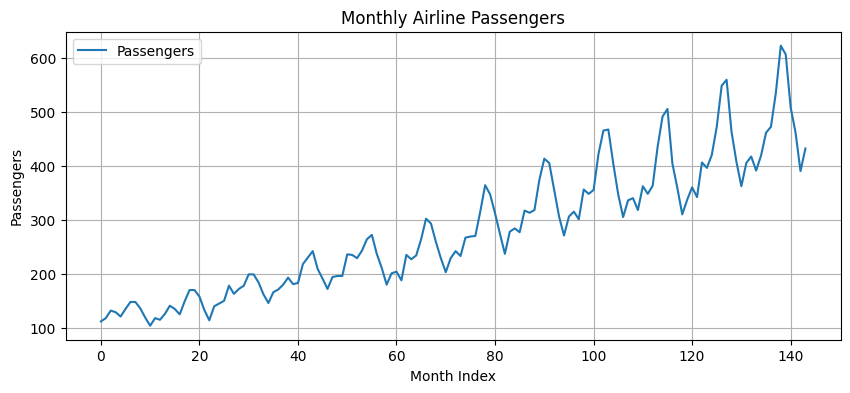

In [4]:
# 그래프 크기를 설정합니다.
# figsize=(10, 4)는 가로 10, 세로 4 크기의 그래프를 의미합니다.
plt.figure(figsize=(10, 4))

# 월별 승객 수를 선 그래프로 그립니다.
# raw["passengers"].values는 승객 수 컬럼을 numpy 배열 형태로 가져옵니다.
plt.plot(raw["passengers"].values, label="Passengers")

# 그래프 제목을 설정합니다.
plt.title("Monthly Airline Passengers")

# x축 이름을 설정합니다.
plt.xlabel("Month Index")

# y축 이름을 설정합니다.
plt.ylabel("Passengers")

# 범례를 표시합니다.
plt.legend()

# 격자선을 표시하여 값의 변화를 더 쉽게 볼 수 있게 합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()


## 5. MinMax 정규화

신경망 모델은 입력값의 범위가 너무 크면 학습이 불안정해질 수 있습니다.  
따라서 승객 수를 0과 1 사이 값으로 변환합니다.


In [5]:
# MinMaxScaler 객체를 생성합니다.
# feature_range=(0, 1)은 데이터의 최솟값을 0, 최댓값을 1로 변환하겠다는 의미입니다.
scaler = MinMaxScaler(feature_range=(0, 1))

# raw 데이터프레임의 passengers 열을 2차원 배열 형태로 변환합니다.
# MinMaxScaler는 입력을 반드시 2차원 배열 형태로 받습니다.
passenger_values = raw[["passengers"]].values

# fit_transform은 최솟값과 최댓값을 학습한 뒤 실제 정규화 변환을 수행합니다.
# scaled_values는 모든 승객 수가 0과 1 사이 값으로 바뀐 결과입니다.
scaled_values = scaler.fit_transform(passenger_values)

# 정규화 결과를 데이터프레임으로 변환하여 확인하기 쉽게 만듭니다.
scaled_df = pd.DataFrame(scaled_values, columns=["scaled_passengers"])

# 정규화된 데이터 앞부분을 출력합니다.
print("정규화 데이터 샘플")
print(scaled_df.head(12))

# 정규화 데이터의 최솟값과 최댓값을 출력합니다.
print("정규화 최솟값:", scaled_values.min())
print("정규화 최댓값:", scaled_values.max())


정규화 데이터 샘플
    scaled_passengers
0            0.015444
1            0.027027
2            0.054054
3            0.048263
4            0.032819
5            0.059846
6            0.084942
7            0.084942
8            0.061776
9            0.028958
10           0.000000
11           0.027027
정규화 최솟값: 0.0
정규화 최댓값: 1.0


## 6. 시계열 입력 데이터와 정답 데이터 생성

LSTM에 넣을 입력 데이터는 `(샘플 수, 시간 길이, 특성 수)` 형태가 되어야 합니다.

예를 들어 과거 12개월을 입력으로 사용한다면 다음과 같이 구성됩니다.

- 입력 X: 1번째 달 ~ 12번째 달
- 정답 y: 13번째 달
- 다음 입력 X: 2번째 달 ~ 13번째 달
- 다음 정답 y: 14번째 달


In [6]:
# 시계열 데이터를 입력 X와 정답 y로 변환하는 함수를 정의합니다.
def make_sequences(data, past_months):
    # 입력 데이터를 저장할 리스트입니다.
    # 각 원소에는 과거 past_months개월의 정규화된 승객 수가 들어갑니다.
    X_list = []

    # 정답 데이터를 저장할 리스트입니다.
    # 각 원소에는 입력 기간 바로 다음 달의 정규화된 승객 수가 들어갑니다.
    y_list = []

    # 전체 데이터에서 과거 입력 길이만큼 제외한 위치까지 반복합니다.
    # 마지막 인덱스에서도 입력 past_months개와 다음 값 1개가 있어야 하기 때문입니다.
    for i in range(len(data) - past_months):
        # i 위치부터 i+past_months 전까지를 입력 데이터로 사용합니다.
        # 예: i=0이면 0번째부터 11번째까지, 총 12개월이 입력입니다.
        X_list.append(data[i : i + past_months])

        # i+past_months 위치의 값을 정답 데이터로 사용합니다.
        # 예: i=0이면 12번째 값, 즉 13번째 달 승객 수가 정답입니다.
        y_list.append(data[i + past_months])

    # 입력 리스트를 numpy 배열로 변환합니다.
    # 최종 모양은 (샘플 수, 시간 길이, 특성 수)가 됩니다.
    X_array = np.array(X_list)

    # 정답 리스트를 numpy 배열로 변환합니다.
    # 최종 모양은 (샘플 수, 1)가 됩니다.
    y_array = np.array(y_list)

    # 입력 배열과 정답 배열을 반환합니다.
    return X_array, y_array

# 정규화된 승객 수 데이터로 시계열 입력과 정답을 생성합니다.
X_data, y_data = make_sequences(scaled_values, PAST_MONTHS)

# TensorFlow/Keras LSTM 입력은 기본적으로 (샘플 수, 시간 길이, 특성 수) 형태를 사용합니다.
# 현재 X_data는 이미 (샘플 수, 12, 1) 형태입니다.
print("X_data shape:", X_data.shape)

# y_data는 각 입력 시퀀스 다음 달 값이므로 (샘플 수, 1) 형태입니다.
print("y_data shape:", y_data.shape)

# 첫 번째 입력 데이터와 정답 데이터를 확인합니다.
print("첫 번째 입력 데이터")
print(X_data[0].flatten())

# 첫 번째 정답 데이터는 첫 번째 입력 다음 달의 정규화된 승객 수입니다.
print("첫 번째 정답 데이터")
print(y_data[0])


X_data shape: (132, 12, 1)
y_data shape: (132, 1)
첫 번째 입력 데이터
[0.015 0.027 0.054 0.048 0.033 0.06  0.085 0.085 0.062 0.029 0.    0.027]
첫 번째 정답 데이터
[0.021]


## 7. 학습 데이터와 테스트 데이터 분리

시계열 데이터는 시간 순서가 중요합니다.  
따라서 데이터를 무작위로 섞지 않고 앞부분은 학습, 뒷부분은 테스트에 사용합니다.


In [7]:
# 전체 샘플 개수에 학습 비율을 곱하여 학습 데이터의 마지막 인덱스를 계산합니다.
train_size = int(len(X_data) * TRAIN_RATIO)

# 앞쪽 데이터를 학습용 입력 데이터로 사용합니다.
# 시계열 데이터에서는 미래 데이터를 학습에 섞으면 안 되므로 순서를 유지합니다.
X_train = X_data[:train_size]

# 뒤쪽 데이터를 테스트용 입력 데이터로 사용합니다.
# 테스트 데이터는 모델이 학습하지 않은 미래 구간 역할을 합니다.
X_test = X_data[train_size:]

# 앞쪽 정답 데이터를 학습용 정답 데이터로 사용합니다.
y_train = y_data[:train_size]

# 뒤쪽 정답 데이터를 테스트용 정답 데이터로 사용합니다.
y_test = y_data[train_size:]

# TensorFlow 모델 학습에 적합하도록 입력 데이터를 float32 자료형으로 변환합니다.
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# TensorFlow 모델 학습에 적합하도록 정답 데이터를 float32 자료형으로 변환합니다.
y_train = y_train.astype("float32")
y_test = y_test.astype("float32")

# 분리된 데이터의 모양을 출력합니다.
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (105, 12, 1)
y_train shape: (105, 1)
X_test shape: (27, 12, 1)
y_test shape: (27, 1)


## 8. TensorFlow Dataset 생성

Keras의 `model.fit()`은 numpy 배열을 바로 받을 수 있습니다.  
하지만 여기서는 PyTorch의 DataLoader와 비슷한 역할을 확인할 수 있도록 `tf.data.Dataset`도 함께 만들어 봅니다.


In [8]:
# tf.data.Dataset.from_tensor_slices는 입력 데이터와 정답 데이터를 샘플 단위로 묶어 Dataset을 생성합니다.
# 각 샘플은 (과거 12개월 입력, 다음 1개월 정답) 구조를 가집니다.
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))

# batch는 데이터를 미니배치 단위로 묶습니다.
# shuffle=False는 시계열 데이터의 시간 순서를 유지하기 위한 설정입니다.
train_dataset = train_dataset.batch(BATCH_SIZE, drop_remainder=False)

# prefetch는 학습 중 다음 배치를 미리 준비하여 학습 속도를 높이는 기능입니다.
# AUTOTUNE은 TensorFlow가 적절한 prefetch 크기를 자동으로 선택하도록 합니다.
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

# 테스트 데이터도 TensorFlow Dataset으로 변환합니다.
# 평가와 예측 단계에서 사용할 수 있습니다.
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

# 테스트 데이터도 학습과 같은 배치 크기로 묶습니다.
test_dataset = test_dataset.batch(BATCH_SIZE, drop_remainder=False)

# 테스트 데이터도 미리 준비할 수 있도록 prefetch를 적용합니다.
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

# 학습 입력 데이터의 모양을 출력하여 LSTM 입력 형태가 올바른지 확인합니다.
print("X_train:", X_train.shape)

# 학습 정답 데이터의 모양을 출력합니다.
print("y_train:", y_train.shape)

# 테스트 입력 데이터의 모양을 출력합니다.
print("X_test:", X_test.shape)

# 테스트 정답 데이터의 모양을 출력합니다.
print("y_test:", y_test.shape)


X_train: (105, 12, 1)
y_train: (105, 1)
X_test: (27, 12, 1)
y_test: (27, 1)


## 9. TensorFlow/Keras LSTM 모델 정의

아래 모델은 과거 12개월 승객 수 흐름을 LSTM으로 처리한 뒤, 마지막 시점의 은닉 출력을 사용하여 다음 달 승객 수를 예측합니다.


In [9]:
# keras.Sequential은 여러 계층을 순서대로 쌓는 가장 간단한 모델 생성 방식입니다.
model = keras.Sequential([
    # Input 계층은 모델이 받을 입력 데이터의 모양을 정의합니다.
    # shape=(PAST_MONTHS, INPUT_SIZE)는 한 샘플이 12개월 길이이고, 각 월마다 특성 1개를 가진다는 뜻입니다.
    layers.Input(shape=(PAST_MONTHS, INPUT_SIZE)),

    # LSTM 계층은 시계열 데이터의 시간적 흐름을 학습하는 순환 신경망 계층입니다.
    # units=HIDDEN_SIZE는 LSTM 은닉 상태 크기를 300으로 설정한다는 의미입니다.
    # return_sequences=False는 모든 시점의 출력을 반환하지 않고 마지막 시점의 출력만 반환한다는 뜻입니다.
    layers.LSTM(units=HIDDEN_SIZE, return_sequences=False),

    # Dense 계층은 LSTM이 만든 마지막 시점의 정보를 최종 예측값 1개로 변환합니다.
    # activation="sigmoid"는 출력값을 0과 1 사이로 제한합니다.
    # 정답 데이터가 MinMaxScaler로 0과 1 사이로 정규화되어 있으므로 출력 범위도 맞춰줍니다.
    layers.Dense(OUTPUT_SIZE, activation="sigmoid")
])

# 모델 구조를 출력합니다.
# 각 계층의 출력 모양과 학습 가능한 파라미터 수를 확인할 수 있습니다.
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 300)            │       362,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           301 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 362,701 (1.38 MB)

 Trainable params: 362,701 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

## 10. 손실 함수와 최적화 알고리즘 설정

이 문제는 실제 승객 수에 가까운 숫자를 예측하는 회귀 문제입니다.  
따라서 평균제곱오차 손실을 사용합니다.

원본 PyTorch 코드와 동일하게 최적화 알고리즘은 `RMSprop`을 사용합니다.


In [10]:
# RMSprop 최적화 알고리즘을 생성합니다.
# RMSprop은 과거 기울기 제곱의 이동 평균을 사용하여 파라미터별 학습률을 조정합니다.
optimizer = keras.optimizers.RMSprop(learning_rate=LEARNING_RATE)

# 손실 함수 이름을 문자열로 지정합니다.
# "mse"는 Mean Squared Error, 즉 평균제곱오차를 의미합니다.
loss_function = "mse"

# 모델의 학습 설정을 compile 메서드로 지정합니다.
# Keras에서는 compile 단계에서 optimizer, loss, metrics를 연결합니다.
model.compile(
    optimizer=optimizer,     # 모델 가중치를 업데이트할 최적화 알고리즘을 지정합니다.
    loss=loss_function,      # 예측값과 실제값의 차이를 계산할 손실 함수를 지정합니다.
    metrics=["mse"]          # 학습 과정에서 MSE 지표를 함께 기록하도록 설정합니다.
)

# 손실 함수와 최적화 알고리즘을 출력합니다.
print("손실 함수:", loss_function)
print("최적화 알고리즘:", optimizer)


손실 함수: mse
최적화 알고리즘: <keras.src.optimizers.rmsprop.RMSprop object at 0x7e6e4d59f4d0>


## 11. 모델 학습

TensorFlow/Keras에서는 PyTorch처럼 직접 반복문을 작성하지 않아도 `model.fit()`으로 학습할 수 있습니다.

학습 과정은 내부적으로 다음 순서로 진행됩니다.

1. 미니배치 입력을 모델에 전달
2. 예측값 계산
3. 손실값 계산
4. 역전파로 기울기 계산
5. 최적화 알고리즘으로 가중치 업데이트


In [11]:
# 학습 시작 시간을 기록합니다.
start_time = time()

# 학습 시작 메시지를 출력합니다.
print("학습 시작")

# model.fit은 Keras 모델을 학습시키는 대표 메서드입니다.
# 여기서는 tf.data.Dataset으로 만든 train_dataset을 입력으로 사용합니다.
history = model.fit(
    train_dataset,             # 미니배치 단위로 구성된 학습 데이터셋입니다.
    epochs=EPOCHS,             # 전체 학습 데이터를 몇 번 반복해서 학습할지 지정합니다.
    verbose=1                  # 학습 진행 상황을 epoch마다 출력합니다.
)

# 학습 종료 시간을 기록합니다.
end_time = time()

# 전체 학습 시간을 출력합니다.
print(f"학습 완료: {end_time - start_time:.2f}초")

# history 객체에는 epoch별 손실값과 지표가 저장되어 있습니다.
# 이후 손실 그래프를 그릴 때 사용합니다.
print("저장된 학습 기록 키:", history.history.keys())


학습 시작
Epoch 1/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0729 - mse: 0.0729
Epoch 2/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0653 - mse: 0.0653
Epoch 3/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.0606 - mse: 0.0606
Epoch 4/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0571 - mse: 0.0571
Epoch 5/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0542 - mse: 0.0542
Epoch 6/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0518 - mse: 0.0518
Epoch 7/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0497 - mse: 0.0497
Epoch 8/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0479 - mse: 0.0479
Epoch 9/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0462 - mse: 0.0462
Epoch 10/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0446 - mse: 0.0446
Epoch 11/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0431 - mse: 0.0431
Epoch 12/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0415 - mse: 0.0415
Epoch 13/300
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48

## 12. 학습 손실 시각화

손실값이 점점 감소하면 모델이 학습 데이터의 패턴을 점차 잘 학습하고 있다는 뜻입니다.


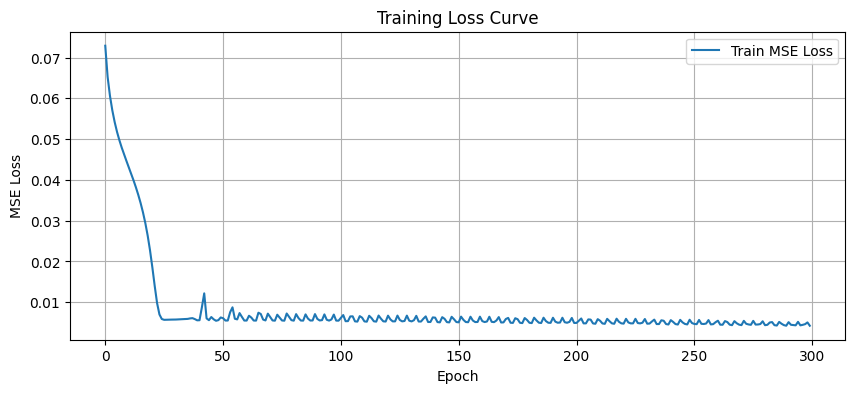

In [12]:
# history.history["loss"]에는 epoch별 학습 손실값이 리스트로 저장되어 있습니다.
train_losses = history.history["loss"]

# 그래프 크기를 설정합니다.
plt.figure(figsize=(10, 4))

# epoch별 학습 손실을 선 그래프로 그립니다.
plt.plot(train_losses, label="Train MSE Loss")

# 그래프 제목을 설정합니다.
plt.title("Training Loss Curve")

# x축 이름을 설정합니다.
plt.xlabel("Epoch")

# y축 이름을 설정합니다.
plt.ylabel("MSE Loss")

# 범례를 표시합니다.
plt.legend()

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()


## 13. 모델 평가

평가 단계에서는 가중치를 업데이트하지 않습니다.  
Keras에서는 `model.evaluate()`를 사용하여 테스트 데이터의 손실값을 계산할 수 있습니다.


In [13]:
# model.evaluate는 테스트 데이터에 대한 손실값과 지표를 계산합니다.
# 반환값은 compile에서 지정한 loss와 metrics 순서에 따라 나옵니다.
test_loss, test_mse = model.evaluate(test_dataset, verbose=0)

# 테스트 손실값을 출력합니다.
print(f"테스트 MSE Loss: {test_loss:.6f}")

# 테스트 지표로 계산된 MSE도 출력합니다.
print(f"테스트 MSE Metric: {test_mse:.6f}")


테스트 MSE Loss: 0.015382
테스트 MSE Metric: 0.015382


## 14. 예측값을 원래 승객 수 단위로 복원

모델은 정규화된 값을 예측합니다.  
사람이 해석하기 쉬운 승객 수 단위로 보기 위해 원래 스케일로 되돌립니다.


In [14]:
# model.predict는 입력 데이터에 대한 예측값을 계산합니다.
# X_test는 (샘플 수, 12, 1) 형태의 테스트 입력 데이터입니다.
test_predictions = model.predict(X_test, verbose=0)

# 예측 결과는 이미 numpy 배열 형태입니다.
# pred_scaled는 0과 1 사이로 정규화된 예측값입니다.
pred_scaled = test_predictions

# truth_scaled는 0과 1 사이로 정규화된 실제 정답값입니다.
truth_scaled = y_test

# 정규화된 예측값을 원래 승객 수 단위로 복원합니다.
# scaler.inverse_transform은 MinMaxScaler가 적용되기 전의 숫자 범위로 되돌립니다.
pred_original = scaler.inverse_transform(pred_scaled)

# 정규화된 실제값을 원래 승객 수 단위로 복원합니다.
truth_original = scaler.inverse_transform(truth_scaled)

# 그래프와 표 출력이 편하도록 1차원 배열로 변환합니다.
pred_original_1d = pred_original.flatten()

# 실제값도 1차원 배열로 변환합니다.
truth_original_1d = truth_original.flatten()

# 원래 단위 기준 평균제곱오차를 계산합니다.
# 값이 작을수록 실제 승객 수와 예측 승객 수의 차이가 작다는 의미입니다.
original_mse = mean_squared_error(truth_original_1d, pred_original_1d)

# 원래 단위 기준 평균제곱근오차를 계산합니다.
# RMSE는 MSE에 제곱근을 씌운 값이라 실제 승객 수 단위로 해석하기 쉽습니다.
original_rmse = np.sqrt(original_mse)

# 평가 지표를 출력합니다.
print(f"원래 승객 수 단위 MSE: {original_mse:.3f}")
print(f"원래 승객 수 단위 RMSE: {original_rmse:.3f}")

# 예측값과 실제값 일부를 표로 비교합니다.
# error는 실제값에서 예측값을 뺀 값입니다.
result_df = pd.DataFrame({
    "truth": truth_original_1d,
    "prediction": pred_original_1d,
    "error": truth_original_1d - pred_original_1d
})

# 결과 앞부분을 출력합니다.
print(result_df.head(10))


원래 승객 수 단위 MSE: 4127.354
원래 승객 수 단위 RMSE: 64.244
        truth  prediction       error
0  359.000000  365.430695   -6.430695
1  310.000000  361.294952  -51.294952
2  337.000000  369.511688  -32.511688
3  360.000000  374.161469  -14.161469
4  342.000000  381.023529  -39.023529
5  406.000000  394.941650   11.058350
6  396.000031  403.661224   -7.661194
7  420.000031  416.085510    3.914520
8  472.000031  427.936462   44.063568
9  548.000000  429.143127  118.856873


## 15. 예측 결과 시각화

아래 그래프에서 실제값 선과 예측값 선이 가까울수록 모델이 테스트 구간의 흐름을 잘 예측한 것입니다.


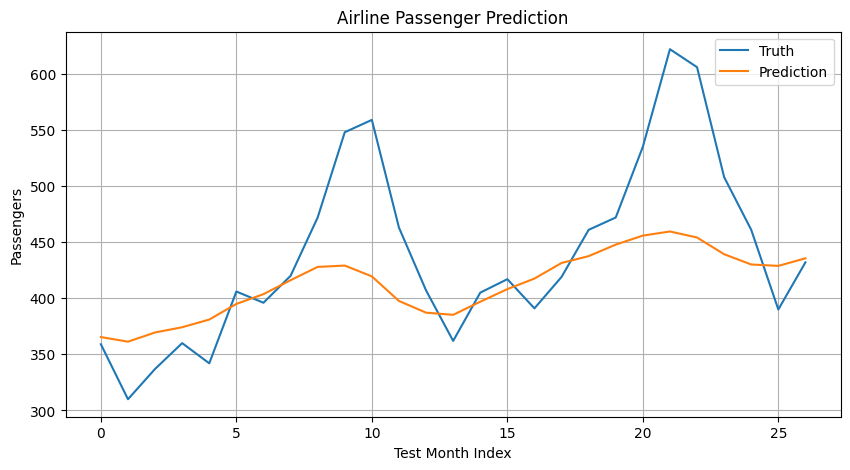

In [15]:
# 그래프 크기를 설정합니다.
plt.figure(figsize=(10, 5))

# 실제 승객 수를 선 그래프로 그립니다.
plt.plot(truth_original_1d, label="Truth")

# 모델 예측 승객 수를 선 그래프로 그립니다.
plt.plot(pred_original_1d, label="Prediction")

# 그래프 제목을 설정합니다.
plt.title("Airline Passenger Prediction")

# x축 이름을 설정합니다.
plt.xlabel("Test Month Index")

# y축 이름을 설정합니다.
plt.ylabel("Passengers")

# 범례를 표시합니다.
plt.legend()

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()


## 16. 다음 1개월 승객 수 예측

마지막 12개월 데이터를 입력으로 사용하면 데이터 이후의 다음 1개월 승객 수를 예측할 수 있습니다.


In [16]:
# 전체 정규화 데이터 중 마지막 12개월 값을 가져옵니다.
# 이 값들이 가장 최근 12개월 승객 수라고 볼 수 있습니다.
last_sequence = scaled_values[-PAST_MONTHS:]

# 모델 입력 형태인 (배치 크기, 시간 길이, 특성 수)로 변환합니다.
# 배치 크기는 1개, 시간 길이는 12개월, 특성 수는 1개입니다.
last_sequence_input = last_sequence.reshape(1, PAST_MONTHS, INPUT_SIZE).astype("float32")

# 마지막 12개월 데이터를 사용하여 다음 1개월 값을 예측합니다.
# 결과는 정규화된 0~1 범위의 값입니다.
next_month_scaled = model.predict(last_sequence_input, verbose=0)

# 정규화된 예측값을 원래 승객 수 단위로 복원합니다.
next_month_prediction = scaler.inverse_transform(next_month_scaled)

# 다음 1개월 예측 승객 수를 출력합니다.
print(f"다음 1개월 예측 승객 수: {next_month_prediction[0, 0]:.2f}")


다음 1개월 예측 승객 수: 440.07


## 17. 전체 흐름 정리

이 노트북의 핵심 흐름은 다음과 같습니다.

1. 월별 항공 승객 수 데이터를 불러옵니다.
2. 데이터를 0과 1 사이로 정규화합니다.
3. 과거 12개월을 입력으로, 다음 1개월을 정답으로 구성합니다.
4. 시계열 순서를 유지한 채 학습 데이터와 테스트 데이터를 나눕니다.
5. 데이터를 TensorFlow/Keras LSTM 입력 형태로 준비합니다.
6. LSTM 모델을 정의하고 평균제곱오차 손실로 학습합니다.
7. 테스트 데이터에서 예측값과 실제값을 비교합니다.
8. 마지막 12개월 데이터로 다음 1개월 승객 수를 예측합니다.
